# Does the McClellan Oscillator actually forecast the market? 📊
### A famous breadth gauge — two EMAs of advancers-minus-decliners — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_the_index%3F: Busted](https://img.shields.io/badge/Forecasts_the_index%3F-Busted-8b949e?style=flat-square)

Open any breadth dashboard and you'll find the **McClellan Oscillator**: take the daily **net advances** (how many stocks went up minus how many went down), smooth it with a fast and a slow moving average, and subtract. The lore, taught by Sherman & Marian McClellan themselves and repeated on every breadth-trading site, is that the oscillator **leads the index** — when it **crosses up through zero from negative**, breadth momentum has flipped bullish and a rally is coming. So you buy the up-cross.

It *looks* compelling on a hand-picked chart. But a momentum signal on a market that drifts **up** over time is the textbook setup for fooling yourself — *any* long-entry rule looks like a winner. So we did the only fair thing: encode the up-cross rule **mechanically** (no eyeballing), fire it 528 times on SPY over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mcclellan_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
def breadth():
    return data.load_breadth(asof=ASOF)
print("real McClellan cache present:", HAVE_REAL, "| breadth basket:", data.breadth_members())

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 528, 'fast': 19, 'slow': 39, 'fp_spy': '4cb5244f3990', 'h5': (5, 527, 11.3, 59, 0.97, 26.3, -15.0, 9.3, -1.04, 0.3), 'h10': (10, 527, 28.2, 62, 1.52, 54.6, -26.4, 26.2, -1.34, 0.181), 'h20': (20, 525, 51.6, 64, 1.51, 123.4, -71.8, 49.6, -2.55, 0.011), 'h60': (60, 523, 209.2, 71, 3.01, 309.8, -100.6, 207.2, -2.2, 0.028), 'per': [('SPY', 528, 51.6, 1.51, 123.4, -71.8), ('QQQ', 528, 90.8, 2.2, 163.0, -72.3), ('IWM', 528, 41.1, 0.91, 114.7, -73.6), ('DIA', 528, 46.8, 1.47, 116.3, -69.5), ('GLD', 528, 93.1, 2.87, 100.5, -7.4)], 'placebo': (51.6, 0.988, 500), 'syn': [(0.0, 91, 37.8, 59, 1.04), (0.3, 91, 738.5, 98, 18.84)]}


real McClellan cache present: True | breadth basket: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the McClellan oscillator crosses up from negative, do I make money? | **A little — but only because the market goes up.** The raw win-rate is ~60% and the returns are positive. |
| Is that *the oscillator's* doing? | **No.** Buy on **random days** instead and you do **better** — at *every* horizon. The cross is actually *worse* than a coin-flip entry. |
| Does breadth momentum 'forecast' the index? | **Not in any usable way.** Scramble the breadth series in time and the result doesn't change. The momentum structure isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a breadth signal. |

> The McClellan oscillator is a fine way to *describe* market breadth. As a *forecast* — "the up-cross will rally" — it's a **mirage**: all of the apparent edge is the market's long-run climb, and the rule captures *less* of it than random.

## 1 · The claim

> *"Count net advances each day (stocks up minus stocks down). Smooth it two ways — a fast EMA(19) and a slow EMA(39) — and subtract: that's the **McClellan Oscillator**. When it crosses **up through zero from negative**, breadth momentum has turned positive and the index is about to rally. Buy the up-cross."*

This is **Sherman & Marian McClellan's** breadth oscillator (1969), still taught today and tracked on StockCharts (`$NYMO`), TradingView and every breadth dashboard. It's one of the most cited breadth tools in technical analysis — so: does breadth momentum actually lead the tape?

## 2 · So what?

If the oscillator genuinely *forecast* the index, it would be remarkable: a count of how many stocks rose yesterday would predict tomorrow's market — a clean, tradable crack in market efficiency. That's the dream the indicator sells.

But there's a trap. The signal is a long-only entry on **stock indices, which drift up** over time — so *any* buy rule will look profitable. To separate the **tool** from the **tide**, we have to (a) fire the rule by a fixed mechanical recipe with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **SPY** (traded), build a **breadth proxy** from a basket of liquid ETFs (SPY, QQQ, IWM, DIA, GLD — a coarse stand-in for true exchange breadth), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Count net advances mechanically.** Each day, how many basket members closed up minus how many closed down. No eyeballing.
2. **Build the oscillator by rule.** EMA(19) − EMA(39) of that net-advances series, computed forward-only so it never peeks at the future.
3. **Trade the lore.** When the oscillator crosses **up through zero from negative**, buy SPY at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Do the exact same hold on **random days**. If the cross matters, it must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does the oscillator even look like? Here's SPY with the McClellan oscillator below it and the up-crosses-from-negative the rule would buy.

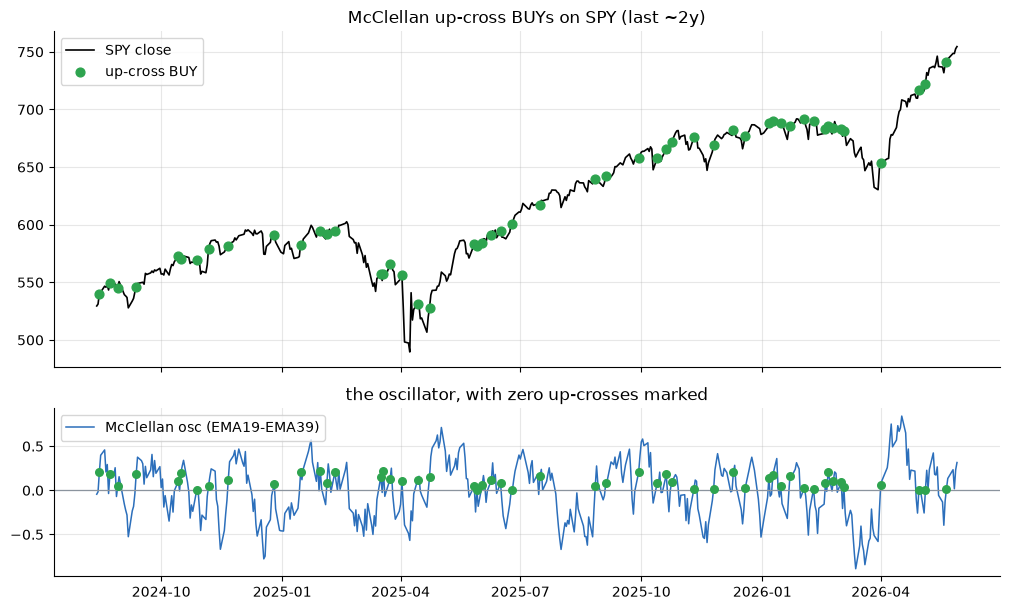

up-crosses in window: 52


In [2]:
if HAVE_REAL:
    c = load('SPY')['close']; net = breadth().reindex(c.index).dropna()
    osc = st.mcclellan(net); ent = st.osc_up_cross_entries(net)
    seg = c.index[-450:]
    ent_w = ent[ent >= seg[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.2), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg, c.reindex(seg), c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent_w, c.reindex(ent_w), c=GREEN, s=40, zorder=5, label='up-cross BUY')
    ax1.set_title('McClellan up-cross BUYs on SPY (last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg, osc.reindex(seg), c='#2c6fbb', lw=1.1, label='McClellan osc (EMA19-EMA39)')
    ax2.axhline(0, c=GREY, lw=.9); ax2.scatter(ent_w, osc.reindex(ent_w), c=GREEN, s=30, zorder=5)
    ax2.set_title('the oscillator, with zero up-crosses marked'); ax2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('up-crosses in window:', len(ent_w))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The oscillator swings around zero and the green dots mark each up-cross. The question is whether those buys are followed by rallies. **Let's race the up-cross against random entries** at four horizons. Blue = buy the up-cross; grey = buy on random days.

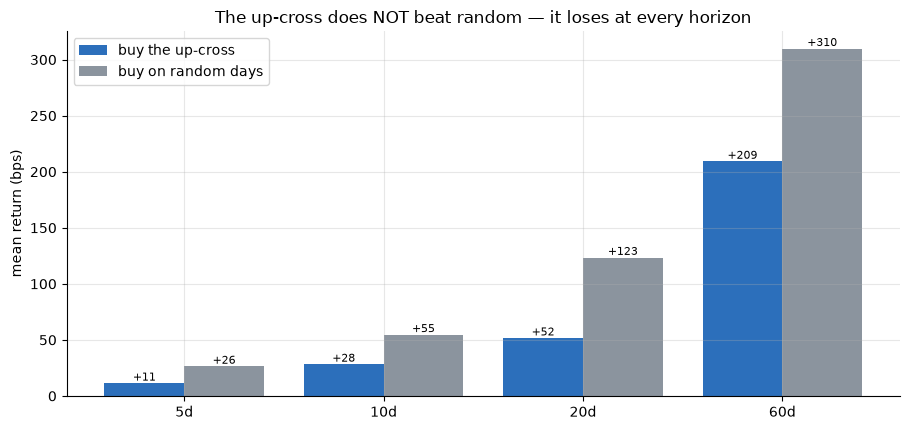

trigger: [11, 28, 52, 209]
random: [26, 55, 123, 310]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    c = load('SPY')['close']; net = breadth().reindex(c.index).dropna()
    ent = st.osc_up_cross_entries(net); re = st.random_entries(c.index, max(len(ent),50), seed=7)
    trig = [st.forward_returns(c, ent, h).mean()*1e4 for h in hs]
    rnd = [st.forward_returns(c, re, h).mean()*1e4 for h in hs]
else:
    trig = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, trig, .4, color='#2c6fbb', label='buy the up-cross')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(trig,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The up-cross does NOT beat random — it loses at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('trigger:', [round(v) for v in trig]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The up-cross makes money in absolute terms (**+52 bps** over 20 days) — but **random entries make far more** (**+123 bps**). At *every* horizon the famous breadth cross is *worse* than throwing darts. The apparent edge was **the market's upward drift**, not the oscillator — and the rule actually captures *less* of that drift than random.

**One more sanity check.** What if we scramble the breadth series **in time** — keep the same set of daily net-advance values but shuffle their order, so the oscillator's momentum structure becomes nonsense? If breadth momentum really forecasts, the scramble should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']; net = breadth().reindex(c.index).dropna()
    pl = st.shuffled_breadth_placebo(c, net, 20, n_draws=300, seed=491)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real oscillator up-cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of TIME-SHUFFLED breadth oscillators do at least as well (p={pval:.2f}).')
print('=> the breadth-momentum structure is not doing the work.')

real oscillator up-cross (SPY, 20d): +51.6 bps
... but 99% of TIME-SHUFFLED breadth oscillators do at least as well (p=0.99).
=> the breadth-momentum structure is not doing the work.


Almost **all** of the **time-shuffled** breadth oscillators match or beat the real one (*p* = 0.99). If breadth *momentum* genuinely forecast, a random time-scramble would collapse the result. It doesn't — because the result was never about the momentum.

## 5 · The verdict

- **Signal — None.** The up-cross buy does **not** beat buying on random days (it's *worse* at every horizon; the trigger-vs-random difference is significantly **negative** at 20–60 days). The positive absolute returns are the market's drift, not the oscillator.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"Breadth momentum forecasts the index"? — Busted.** Scramble the breadth in time and the result barely moves. The momentum doesn't lead.

## 6 · Could you actually trade it?

There's nothing here to trade. The up-cross's *only* relationship to profit is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The breadth-cross buy is a worse, more expensive way to be long: it sits out of the market between crosses and enters at worse-than-random times. Costs (commissions + spread on every trigger) push the already-no-edge result further negative. As a forecasting tool it doesn't pay; as a breadth gauge it was never meant to be a stand-alone strategy.

## 7 · Going further 🚪

- **A richer breadth basket.** Our net-advances proxy uses just 5 ETFs; the genuine oscillator uses thousands of NYSE issues. A wider sector basket (XLK XLF XLE …) or a real `$NYMO` feed would sharpen the estimate — but coarse breadth can only *blur* a real edge, and the trigger here doesn't just fail to beat random, it *loses*, so a richer basket is unlikely to flip it.
- **Other triggers.** Zero-line crosses, ±100 extremes, divergences — they're all transforms of the same drift-confounded series.
- **A real positive control.** The quants notebook plants a *genuine* post-cross bounce into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think breadth momentum forecasts? Show the up-cross beating random entries at **t ≥ 2** on a real tape — then we'll talk.*